In [6]:
import pandas as pd

df = pd.read_csv("data/sales_data.csv")

df.head()

,order_id,order_date,region,product_category,quantity,sales,profit
0,1,2023-01-01 00:00:00,East,Office Supplies,4,296,50
1,2,2023-01-01 01:00:00,West,Furniture,4,213,29
2,3,2023-01-01 02:00:00,North,Electronics,3,234,102
3,4,2023-01-01 03:00:00,East,Furniture,1,198,97
4,5,2023-01-01 04:00:00,East,Office Supplies,2,162,103


In [8]:
df["order_date"] = pd.to_datetime(df["order_date"])

df.isnull().sum()

order_id            0
order_date          0
region              0
product_category    0
quantity            0
sales               0
profit              0
dtype: int64

In [9]:
monthly_sales = df.groupby(
df["order_date"].dt.month
)["sales"].sum()

monthly_sales

order_date
1     583344
2     521074
3     569142
4     451580
5     391345
6     372622
7     388596
8     385408
9     378980
10    390503
11    373882
12    381673
Name: sales, dtype: int64

In [10]:
df.groupby("region")["sales"].sum()

region
East     1275175
North    1322338
South    1287979
West     1302657
Name: sales, dtype: int64

In [11]:
df.groupby("product_category")["sales"].sum()

product_category
Electronics        1747451
Furniture          1719343
Office Supplies    1721355
Name: sales, dtype: int64

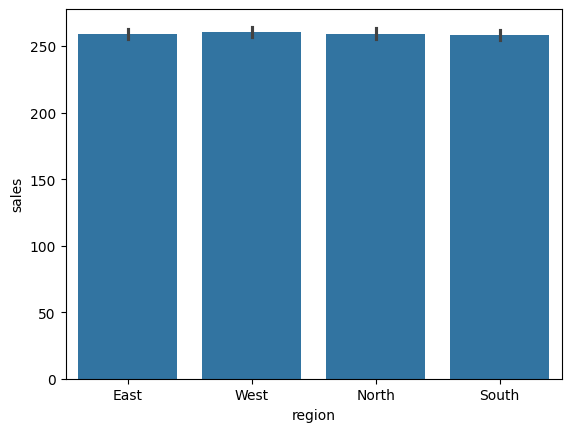

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="region",y="sales",data=df)

plt.savefig("visuals/region_sales.png")

In [18]:
df["month"] = df["order_date"].dt.month
df["year"] = df["order_date"].dt.year

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df[["month","year","quantity"]]
y = df["sales"]

X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2
)

model = RandomForestRegressor()

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
predictions = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,predictions)

print("Model Error:",mae)

Model Error: 119.65042139762093


In [23]:
df_encoded = pd.get_dummies(df, columns=["region","product_category"])

In [24]:
X = df_encoded.drop(columns=["sales","order_date"])
y = df_encoded["sales"]

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestRegressor()

model.fit(X_train,y_train)

predictions = model.predict(X_test)

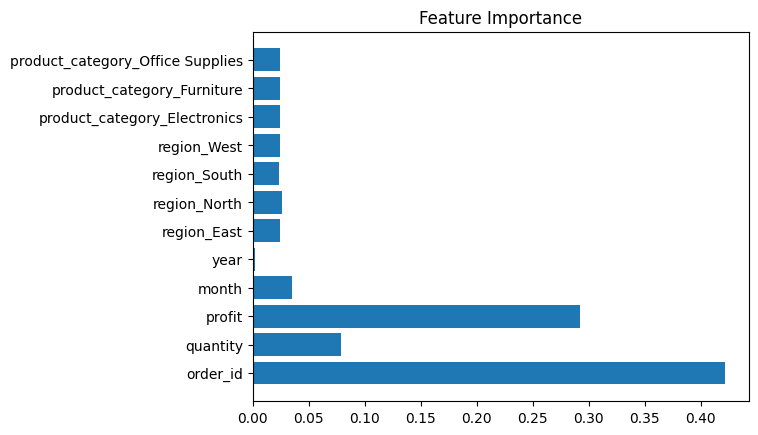

In [26]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = X.columns

plt.barh(features, importance)

plt.title("Feature Importance")

plt.show()

In [27]:
plt.savefig("visuals/feature_importance.png")

<Figure size 640x480 with 0 Axes>